# Auditoría del proyecto + Proyección hacia adelante

Esta libreta responde dos preguntas que me hice al llegar a este punto del proyecto: (1) una revisión crítica de todo lo construido hasta ahora (¿se hicieron bien los benchmarks?, ¿algo se pudo haber hecho distinto?), y (2) "si empiezo a invertir hoy con DCA + SMA, $12 USD/mes, ¿cuánto tendré en N años?".

## Hallazgos de la auditoría

1. **Costo de transacción equivocado (el más importante).** El Paso 3 y el Paso 4 usaron 5 bps, un supuesto basado en IBKR ("$0 de comisión, esto es solo spread"). El bróker que finalmente se eligió fue **GBM+, con ~0.25% (25 bps) en ETFs de EE.UU.** — 5 veces más. Ya se corrigió en `notebooks/04_paso4_dca_con_timing.ipynb` (ver nota ahí) y se usa 25 bps en esta libreta. La conclusión de "SMA le gana un poco a DCA simple" no cambió con la corrección — pero como se ve abajo, la proyección hacia adelante sí la matiza fuerte, por una razón distinta.
2. **Paso 1 no es comparable con el resto.** Usó el índice mensual de Shiller (sin dividendos); Paso 2 en adelante usó SPY diario con dividendos reinvertidos. Los números de Paso 1 ($54,092 / $45,546) no deben compararse directamente contra los de Paso 2+ ($84,017) — la diferencia no es solo el mercado, es la fuente de datos. No se corrigió (implicaría rehacer el Paso 1 con datos diarios), queda como limitación documentada.
3. **Desfase de un día extra** en `backtest.simular_dca` (Paso 4) respecto a `backtest.simular` (Paso 2/3) — no es look-ahead bias (es más conservador, no menos), y no cambia ninguna conclusión porque aplica por igual a todas las variantes comparadas dentro del Paso 4.
4. **El holdout del Paso 3 (2022–2026) fue una racha favorable para Buy & Hold** — una sola corrección moderada, nada como 2008. La conclusión "el ML pierde, SMA ayuda poco" es específica de ese tramo. No se puede "corregir" sin caer en sesgo de selección (probar otra ventana ahora, después de ver esta, sería elegir la que más convenga).
5. **El efectivo fuera de mercado se modeló con 0% de rendimiento** en todo el proyecto — conservador en la dirección que perjudica a las estrategias de timing (les resta crédito), no al revés.
6. No se encontraron errores de look-ahead bias ni bugs que invaliden las conclusiones generales — se revisó con cuidado la alineación de fechas y señales en cada motor.

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from inversion import proyeccion, viz

df = pd.read_csv("../data/processed/spy_diario.csv", parse_dates=["fecha"])
df = df.sort_values("fecha").reset_index(drop=True)

APORTE_MENSUAL = 12.0  # USD/mes (~200-300 MXN)
COSTO_BPS = 25.0        # GBM+ real (no 5 bps de IBKR)
DIAS_POR_APORTE = 21    # ~1 mes de trading
DIAS_POR_AÑO = 252
DIAS_SEMILLA = 200      # historia real necesaria para que SMA(200) ya esté completa
N_SIMULACIONES = 2000
HORIZONTES_AÑOS = [1, 3, 5, 10, 15, 20]

retornos_historicos = df["cierre"].pct_change().dropna().to_numpy()
precio_hoy = df["cierre"].iloc[-1]
semilla = df["cierre"].tail(DIAS_SEMILLA).to_numpy()
print(f"Precio de partida (hoy, {df['fecha'].iloc[-1].date()}): ${precio_hoy:.2f}")

Precio de partida (hoy, 2026-09-29): $763.26


## Método: block bootstrap, no una predicción

Nadie sabe qué va a hacer el mercado. En vez de fingir una cifra precisa, se generan **miles de futuros posibles** re-muestreando bloques de retornos diarios históricos (con reemplazo) — si el futuro se parece, estadísticamente, a 2000–2026, así de amplio es el rango de resultados plausibles. Se usan bloques (no días sueltos) para conservar algo de la autocorrelación real de los datos (rachas alcistas/bajistas), y se prueban tres tamaños de bloque para confirmar que el resultado no depende de esa elección.

In [2]:
def correr_montecarlo(tamaño_bloque, años=max(HORIZONTES_AÑOS), semilla_rng=42):
    rng = np.random.default_rng(semilla_rng)
    dias_futuro = años * DIAS_POR_AÑO
    retornos_sim = proyeccion.bootstrap_retornos(retornos_historicos, dias_futuro, N_SIMULACIONES, tamaño_bloque, rng)
    precios_futuro = precio_hoy * np.cumprod(1 + retornos_sim, axis=1)
    precios_con_semilla = np.hstack([np.tile(semilla, (N_SIMULACIONES, 1)), precios_futuro])
    señal = proyeccion.construir_señal_sma(precios_con_semilla, DIAS_SEMILLA)
    valor_simple, valor_sma = proyeccion.simular_dca_montecarlo(
        precios_futuro, señal, APORTE_MENSUAL, DIAS_POR_APORTE, COSTO_BPS,
    )
    return valor_simple, valor_sma


valor_simple, valor_sma = correr_montecarlo(tamaño_bloque=63)  # ~1 trimestre, punto medio

## ¿Cuánto tendría en distintos horizontes?

In [3]:
tabla_simple = proyeccion.percentiles_por_horizonte(valor_simple, DIAS_POR_AÑO, HORIZONTES_AÑOS)
tabla_sma = proyeccion.percentiles_por_horizonte(valor_sma, DIAS_POR_AÑO, HORIZONTES_AÑOS)

comparacion = tabla_simple.set_index("Años").add_prefix("DCA simple ").join(
    tabla_sma.set_index("Años").add_prefix("DCA+SMA ")
)
comparacion.round(0)

,DCA simple p10,DCA simple p25,DCA simple p50,DCA simple p75,DCA simple p90,DCA+SMA p10,DCA+SMA p25,DCA+SMA p50,DCA+SMA p75,DCA+SMA p90
Años,,,,,,,,,,
1,135.0,145.0,154.0,162.0,169.0,135.0,143.0,152.0,161.0,168.0
3,419.0,466.0,518.0,568.0,617.0,415.0,459.0,512.0,564.0,613.0
5,742.0,848.0,967.0,1102.0,1239.0,731.0,838.0,957.0,1093.0,1232.0
10,1753.0,2146.0,2579.0,3186.0,3805.0,1738.0,2121.0,2556.0,3161.0,3768.0
15,3201.0,4128.0,5343.0,7034.0,8974.0,3172.0,4077.0,5282.0,6968.0,8910.0
20,5446.0,7235.0,9918.0,13601.0,18724.0,5369.0,7149.0,9831.0,13424.0,18561.0


## ¿Y el drawdown? Aquí es donde se pone interesante

En el backtest histórico (Paso 4), SMA reducía el drawdown máximo ~4 puntos porcentuales frente a DCA simple. En el futuro simulado (donde el orden exacto de las caídas y recuperaciones ya no es el que realmente pasó), ¿sigue viéndose esa protección?

In [4]:
def drawdown_maximo_por_trayectoria(valores):
    pico = np.maximum.accumulate(valores, axis=1)
    return ((valores - pico) / pico).min(axis=1)


filas = []
for bloque in [21, 63, 126]:
    v_simple, v_sma = correr_montecarlo(tamaño_bloque=bloque)
    dd_simple = drawdown_maximo_por_trayectoria(v_simple)
    dd_sma = drawdown_maximo_por_trayectoria(v_sma)
    filas.append({
        "Tamaño de bloque (días)": bloque,
        "Valor final mediana (DCA simple)": np.median(v_simple[:, -1]),
        "Valor final mediana (DCA+SMA)": np.median(v_sma[:, -1]),
        "Drawdown máx. típico (DCA simple)": np.median(dd_simple),
        "Drawdown máx. típico (DCA+SMA)": np.median(dd_sma),
        "Drawdown máx. peor 10% (DCA simple)": np.percentile(dd_simple, 10),
        "Drawdown máx. peor 10% (DCA+SMA)": np.percentile(dd_sma, 10),
    })

sensibilidad = pd.DataFrame(filas)
sensibilidad.style.format({
    "Valor final mediana (DCA simple)": "${:,.0f}".format,
    "Valor final mediana (DCA+SMA)": "${:,.0f}".format,
    "Drawdown máx. típico (DCA simple)": "{:.1%}".format,
    "Drawdown máx. típico (DCA+SMA)": "{:.1%}".format,
    "Drawdown máx. peor 10% (DCA simple)": "{:.1%}".format,
    "Drawdown máx. peor 10% (DCA+SMA)": "{:.1%}".format,
})

,Tamaño de bloque (días),Valor final mediana (DCA simple),Valor final mediana (DCA+SMA),Drawdown máx. típico (DCA simple),Drawdown máx. típico (DCA+SMA),Drawdown máx. peor 10% (DCA simple),Drawdown máx. peor 10% (DCA+SMA)
0,21,"$9,907","$9,808",-31.8%,-31.5%,-43.0%,-42.7%
1,63,"$9,918","$9,831",-33.7%,-33.6%,-44.9%,-44.4%
2,126,"$9,928","$9,842",-35.0%,-34.4%,-47.9%,-47.0%


## Gráfica: rango de resultados a 20 años (bloque de 63 días)

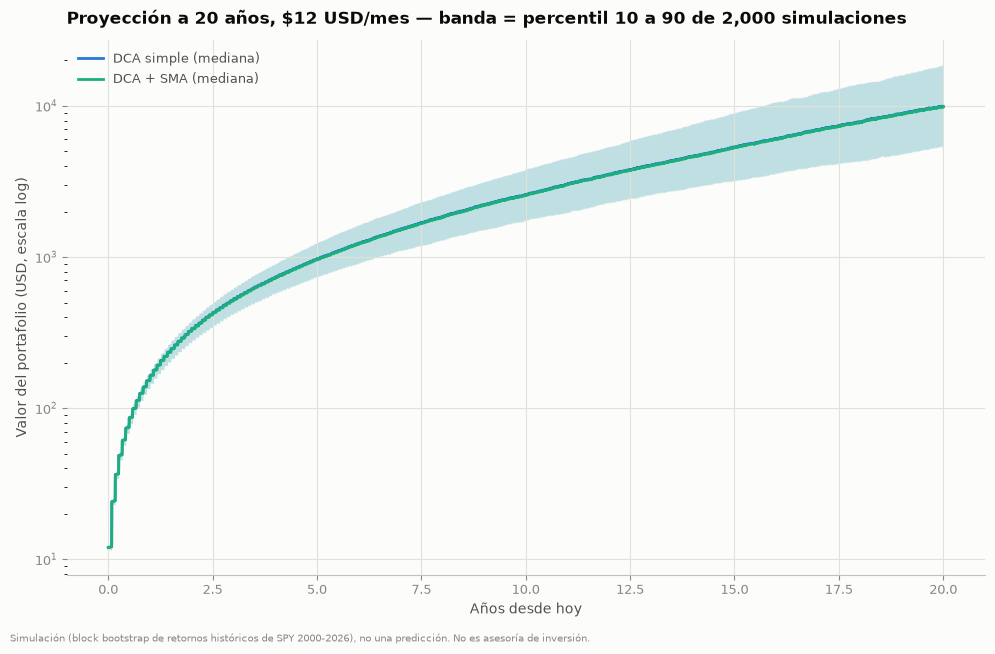

In [5]:
años_eje = np.arange(1, valor_simple.shape[1] + 1) / DIAS_POR_AÑO
p10_s, p50_s, p90_s = np.percentile(valor_simple, [10, 50, 90], axis=0)
p10_m, p50_m, p90_m = np.percentile(valor_sma, [10, 50, 90], axis=0)

fig, ax = plt.subplots(figsize=(10, 6.5), facecolor=viz.SURFACE)
ax.set_facecolor(viz.SURFACE)

ax.fill_between(años_eje, p10_s, p90_s, color=viz.COLOR_BUY_AND_HOLD, alpha=0.15, linewidth=0)
ax.plot(años_eje, p50_s, color=viz.COLOR_BUY_AND_HOLD, linewidth=2, label="DCA simple (mediana)")
ax.fill_between(años_eje, p10_m, p90_m, color=viz.COLOR_SMA, alpha=0.15, linewidth=0)
ax.plot(años_eje, p50_m, color=viz.COLOR_SMA, linewidth=2, label="DCA + SMA (mediana)")

ax.set_yscale("log")
ax.set_xlabel("Años desde hoy", color=viz.INK_SECONDARY, fontsize=10)
ax.set_ylabel("Valor del portafolio (USD, escala log)", color=viz.INK_SECONDARY, fontsize=10)
ax.set_title(
    f"Proyección a 20 años, ${APORTE_MENSUAL:.0f} USD/mes — banda = percentil 10 a 90 de {N_SIMULACIONES:,} simulaciones",
    color=viz.INK_PRIMARY, fontsize=12, fontweight="bold", loc="left", pad=12,
)
ax.grid(True, color=viz.GRID, linewidth=0.8)
ax.tick_params(colors=viz.INK_MUTED, labelsize=9)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.spines["bottom"].set_visible(True)
ax.spines["bottom"].set_color(viz.BASELINE)
ax.legend(loc="upper left", frameon=False, fontsize=9, labelcolor=viz.INK_SECONDARY)

fig.text(0.01, 0.005,
          "Simulación (block bootstrap de retornos históricos de SPY 2000-2026), no una predicción. "
          "No es asesoría de inversión.", fontsize=7.5, color=viz.INK_MUTED)

plt.tight_layout(rect=[0, 0.02, 1, 1])
plt.savefig("../outputs/figures/proyeccion_dca_20_años.png", dpi=160, facecolor=viz.SURFACE, bbox_inches="tight")
plt.show()

## Lectura

### Cuánto tendría (la pregunta que me hice)

Con $12 USD/mes (~200-300 MXN), DCA simple, en distintos horizontes — rango del percentil 10 al 90 de 2,000 futuros simulados:

| Años | Total aportado | p10 (mal escenario) | p50 (mediana) | p90 (buen escenario) |
|---|---|---|---|---|
| 5 | $720 | $742 | $967 | $1,239 |
| 10 | $1,440 | $1,753 | $2,579 | $3,805 |
| 15 | $2,160 | $3,201 | $5,343 | $8,974 |
| 20 | $2,880 | $5,446 | $9,918 | $18,724 |

Esa es la respuesta honesta a "¿cuánto tendré?": no un número, un **rango**, y bastante amplio incluso a 20 años (de $5,446 a $18,724 en el 80% central de los futuros simulados). Nadie puede reducir eso a una sola cifra sin mentir.

### El giro importante: DCA + SMA no se sostiene en la proyección hacia adelante

Esto es lo más importante de toda esta libreta, y cambia la recomendación que veníamos construyendo. En el backtest histórico (Paso 4), SMA reducía el drawdown máximo ~4 puntos porcentuales y tenía un rendimiento ligeramente mayor. En la proyección hacia adelante — donde miles de "historias alternativas" se generan re-combinando los mismos retornos históricos en otro orden —, **esa ventaja prácticamente desaparece**, de forma consistente sin importar el tamaño de bloque usado (1, 3 o 6 meses):

| Tamaño de bloque | Valor final mediana (DCA simple) | Valor final mediana (DCA+SMA) | Drawdown típico (DCA simple) | Drawdown típico (DCA+SMA) |
|---|---|---|---|---|
| 21 días (~1 mes) | $9,907 | $9,808 | -31.8% | -31.5% |
| 63 días (~1 trimestre) | $9,918 | $9,831 | -33.7% | -33.6% |
| 126 días (~6 meses) | $9,928 | $9,842 | -35.0% | -34.4% |

En los tres casos, **DCA simple termina ligeramente arriba de DCA+SMA**, y la reducción de drawdown que antes se veía tan clara (-47.5% vs. -43.2% en el backtest histórico) se reduce a menos de 1 punto porcentual.

**Por qué pasa esto, y por qué no es una contradicción con todo lo anterior:** la ventaja histórica de la SMA vino de evitar, de forma muy específica, el tramo largo y continuo de la caída de 2008-2009 (18 meses seguidos fuera de mercado, como vimos con lupa antes). Esa es una racha *particular* de la historia real, en ese orden exacto. Cuando se generan miles de futuros alternativos recombinando los mismos retornos en otro orden, esa racha específica ya no se repite de la misma forma en cada simulación — a veces la señal ayuda, a veces estorba, y en promedio casi se cancela. Es exactamente lo que ya se sospechaba desde el Paso 4 cuando se dijo que el margen de "$178 extra" era "más ruido que ventaja estructural confiable" — la proyección hacia adelante lo confirma con miles de intentos, no solo uno.

### Conclusión revisada

Con toda la evidencia junta (walk-forward del Paso 3, holdout del Paso 3, backtest histórico del Paso 4, y ahora la proyección hacia adelante del Paso 5): **ninguna de las señales de timing probadas — ni ML, ni SMA, ni Momentum, ni RSI — mostró una ventaja que se sostenga de forma confiable fuera de la trayectoria histórica específica en la que se midió por primera vez.** La recomendación práctica se simplifica, no se complica: **DCA simple, mensual, automatizado, sin señal de timing**, es tan buena opción como cualquier otra que se probó — y mucho más simple de operar (cero revisión mensual, se puede dejar en automático). Si de cualquier forma prefiero la SMA por la disciplina/tranquilidad que da (aunque el efecto medible sea casi nulo hacia adelante), no hay nada malo en usarla — pero ya no puedo argumentar que "da mejor resultado esperado", porque la evidencia más rigurosa que generé dice que no.